--- نتایج پرسپترون برای گیت AND ---
وزن‌های نهایی: Bias (w0) = -0.20, w1 = 0.20, w2 = 0.10
تست شبکه (پیش‌بینی‌ها):
Input: [0 0] | Target: 0 | Prediction: 0 | ✓
Input: [0 1] | Target: 0 | Prediction: 0 | ✓
Input: [1 0] | Target: 0 | Prediction: 0 | ✓
Input: [1 1] | Target: 1 | Prediction: 1 | ✓
----------------------------------------


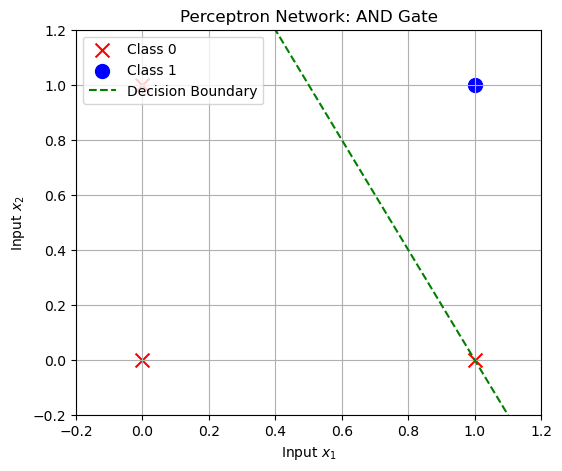

--- نتایج پرسپترون برای گیت OR ---
وزن‌های نهایی: Bias (w0) = -0.10, w1 = 0.10, w2 = 0.10
تست شبکه (پیش‌بینی‌ها):
Input: [0 0] | Target: 0 | Prediction: 0 | ✓
Input: [0 1] | Target: 1 | Prediction: 1 | ✓
Input: [1 0] | Target: 1 | Prediction: 1 | ✓
Input: [1 1] | Target: 1 | Prediction: 1 | ✓
----------------------------------------


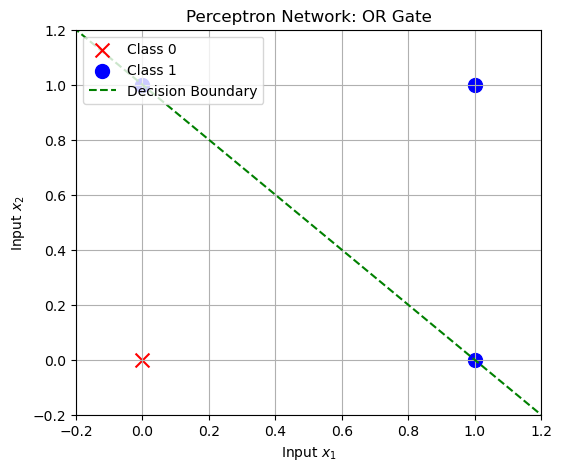

--- نتایج پرسپترون برای گیت XOR ---
وزن‌های نهایی: Bias (w0) = 0.00, w1 = -0.10, w2 = 0.00
تست شبکه (پیش‌بینی‌ها):
Input: [0 0] | Target: 0 | Prediction: 1 | ✗ (خطا)
Input: [0 1] | Target: 1 | Prediction: 1 | ✓
Input: [1 0] | Target: 1 | Prediction: 0 | ✗ (خطا)
Input: [1 1] | Target: 0 | Prediction: 0 | ✓
----------------------------------------


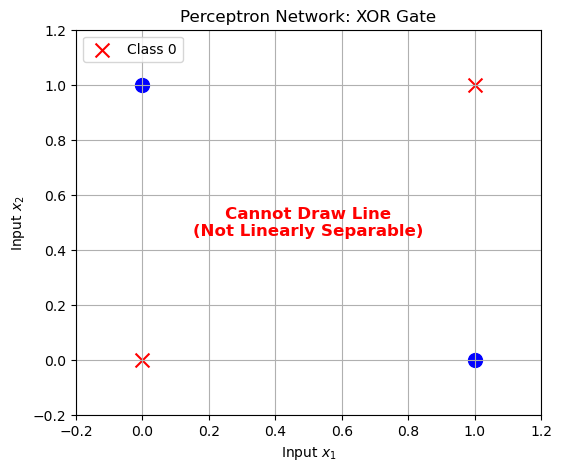

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def perceptron_learning(X, Y, gate_name, epochs=100, alpha=0.1):
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        for i in range(len(X)):
            # NET = w0*1 + w1*x1 + w2*x2
            net_input = np.dot(X[i], w)
            # تابع فعال‌ساز
            y_pred = 1 if net_input >= 0 else 0
            error = Y[i] - y_pred
            
            #IF Y[i] == 1 and y_pred == 0, then w_new = w_old + X[i]
            #IF Y[i] == 0 and y_pred == 1, then w_new = w_old - X[i]
            if error != 0: 
                # w_new = w_old + (error * X[i] * alph)
                # IF X[i] == 1 then w_new = w_old + (Y[i] − y_pred)
                w = w + (alpha * error * X[i])
            
    print(f"--- نتایج پرسپترون برای گیت {gate_name} ---")
    print(f"وزن‌های نهایی: Bias (w0) = {w[0]:.2f}, w1 = {w[1]:.2f}, w2 = {w[2]:.2f}")
    
    # ۳. تست شبکه 
    print("تست شبکه (پیش‌بینی‌ها):")
    success = True
    for i in range(len(X)):
        net_input = np.dot(X[i], w)
        y_pred = 1 if net_input >= 0 else 0
        # وضعیت موفقیت مدل
        if y_pred != Y[i]:
            success = False
        x_disp = X[i][1:] # حذف عدد 1 مربوط به بایاس برای نمایش
        y_disp = Y[i]
        print(f"Input: {x_disp} | Target: {y_disp} | Prediction: {y_pred} | {'✓' if y_disp == y_pred else '✗ (خطا)'}")
    print("-" * 40)
    
    # ۴. رسم نمودار
    plot_decision_boundary(X, Y, w, gate_name, success)

def plot_decision_boundary(X, Y, w, gate_name, success):
    plt.figure(figsize=(6, 5))
    
    # (کلاس 0 = قرمز، کلاس 1 = آبی)
    for i in range(len(X)):
        if Y[i] == 1:
            plt.scatter(X[i, 1], X[i, 2], color='blue', marker='o', s=100, label='Class 1' if i==3 else "")
        else:
            plt.scatter(X[i, 1], X[i, 2], color='red', marker='x', s=100, label='Class 0' if i==0 else "")

    if success:
        # معادله خط: w0 + w1*x1 + w2*x2 = 0 =>  x2 = -(w1/w2)*x1 - (w0/w2)
        if abs(w[2]) > 1e-6: 
            x1_vals = np.array([-1.5, 1.5])
            x2_vals = -(w[1] / w[2]) * x1_vals - (w[0] / w[2])
            plt.plot(x1_vals, x2_vals, color='green', linestyle='--', label='Decision Boundary')
    else:
        plt.text(0.5, 0.5, "Cannot Draw Line\n(Not Linearly Separable)", color='red', ha='center', va='center', fontsize=12, weight='bold')

    plt.title(f"Perceptron Network: {gate_name} Gate")
    plt.xlabel("Input $x_1$")
    plt.ylabel("Input $x_2$")
    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.grid(True)
    
    # مرتب‌سازی راهنما (Legend)
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.show()

#################################

# ============== Input ==============
X_binary = np.array([
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

# ============== Target ==============
Y_AND = np.array([0, 0, 0, 1])
Y_OR  = np.array([0, 1, 1, 1])
Y_XOR = np.array([0, 1, 1, 0])

# ============== RUN ==============

perceptron_learning(X_binary, Y_AND, "AND")
perceptron_learning(X_binary, Y_OR, "OR")
perceptron_learning(X_binary, Y_XOR, "XOR")
